In [5]:
from __future__ import annotations
import sys
from pathlib import Path

# Setup path
ROOT = Path.cwd().resolve()
if not (ROOT / "qos.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

import qos
import utils

SEED = 0
key = random.PRNGKey(SEED)
print("Setup complete!")

Setup complete!


In [ ]:
from jax import random
import jax.numpy as jnp
import qos

#Validate the error of the sketching method for different sample sizes M
SEED = 0
key = random.PRNGKey(SEED)

sample_sizes = [2000, 5000, 10000, 20000, 50000]
errors = []

# Use dimension 1000 and degree=20 exactly like the source
N = 1000
key, subkey = random.split(key)
v_raw = random.normal(subkey, (N,), dtype=jnp.float32)
v = v_raw / jnp.linalg.norm(v_raw)

for M in sample_sizes:
    key, subkey = random.split(key)
    state, _ = qos.q_state_sketch(v, subkey, M, degree=20)
    # Normalize error exactly like the source
    error = float(jnp.linalg.norm(v - state / jnp.linalg.norm(state)))
    errors.append((M, error))
    print(f"M={M:>6} -> error={error:.3e}")

print("\nDone!")
print("Errors:", errors)

[PolyTaylorSeries] (Cheb) average error = 2.995868236391197e-08 in the domain [-0.8414709848078965, 0.8414709848078965] using degree 20
[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.211e-01
iter: 002 --- err: 1.620e-02
iter: 003 --- err: 5.962e-04
iter: 004 --- err: 9.525e-07
iter: 005 --- err: 2.448e-12
iter: 006 --- err: 7.212e-16
[sym_qsp] Stop criteria satisfied.
M=  2000 -> error=5.810e-04
[PolyTaylorSeries] (Cheb) average error = 2.995868236391197e-08 in the domain [-0.8414709848078965, 0.8414709848078965] using degree 20
[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.211e-01
iter: 002 --- err: 1.620e-02
iter: 003 --- err: 5.962e-04
iter: 004 --- err: 9.525e-07
iter: 005 --- err: 2.448e-12
iter: 006 --- err: 7.212e-16
[sym_qsp] Stop criteria satisfied.
M=  5000 -> error=1.976e-04
[PolyTaylorSeries] (Cheb) average error = 2.995868236391197e-08 in the domain [-0.8414709848078965, 0.8414709848078965] 

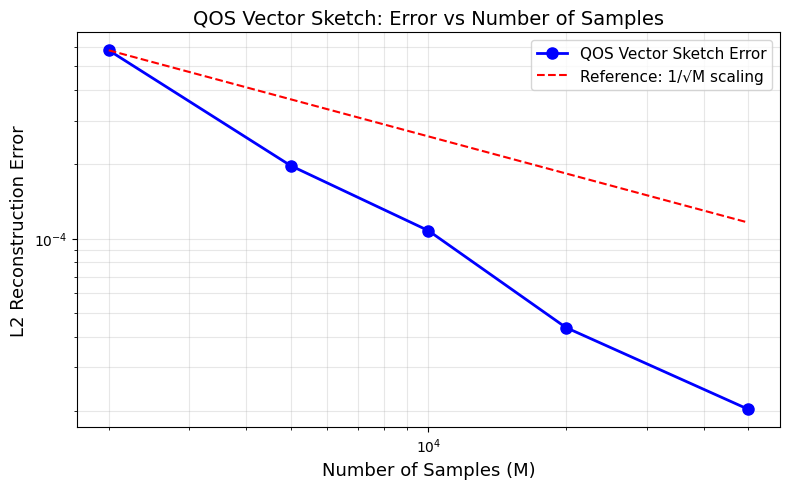

Plot saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract Ms and errors for plotting
Ms = [e[0] for e in errors]
errs = [e[1] for e in errors]
 
# Plotting the error vs M on a log-log scale
plt.figure(figsize=(8, 5))
plt.loglog(Ms, errs, 'bo-', linewidth=2, markersize=8, label='QOS Vector Sketch Error')

# Add a reference line showing ideal 1/sqrt(M) scaling
ref = [errs[0] * (Ms[0] / m) ** 0.5 for m in Ms]
plt.loglog(Ms, ref, 'r--', linewidth=1.5, label='Reference: 1/√M scaling')

plt.xlabel('Number of Samples (M)', fontsize=13)
plt.ylabel('L2 Reconstruction Error', fontsize=13)
plt.title('QOS Vector Sketch: Error vs Number of Samples', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('qos_vector_sketch_error.png', dpi=150)
plt.show()
print("Plot saved!")

In [ ]:
import inspect
print(inspect.signature(qos.q_state_sketch))
print("\n")
print(inspect.getsource(qos.q_state_sketch))

# The function `q_state_sketch` takes the following parameters:
# trying to compare random sampling vs unitary sampling,

(vector, key, unit_num_samples, angle_set=None, degree=4)


def q_state_sketch(vector, key, unit_num_samples, angle_set=None, degree=4):
    """
    Construct the quantum state sketch of a general vector.

    Use 2 ancilla qubit.
    One for the first LCU and QSVT, one for the second LCU to extract real part.

    Args:
        vector: array of shape (dim,), the input vector
        key: jax.random.PRNGKey, random key for generating random signs
        unit_num_samples: int, number of samples to use in each sketch
        angle_set (optional): array of shape (num_angles,), pre-computed angle set for QSVT;
            if None, compute internally
        degree: even int, degree of the polynomial approximation for arcsin(x), default 4

    Returns:
        (state, num_samples): quantum state sketch as an array of shape (dim,) and the number of samples used

    """
    orig_dim = vector.shape[0]
    dim = int(2 ** jnp.ceil(jnp.log2(vector.shape[0])))
    prob = jnp.ones_like(vector, dt